In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import re

print(" Loading the full dataset (1.1 Million rows)...")

df = pd.read_csv('/content/drive/MyDrive/project data/twcs/twcs.csv', low_memory=False)

# 2. فصل الأسئلة والردود بناءً على الـ inbound (زي ما هو واضح في image_e84023.png)
print("🔍 Splitting into Questions and Answers...")
questions = df[df['inbound'] == True][['tweet_id', 'text']].rename(columns={'text': 'question_text'})
answers = df[df['inbound'] == False][['in_response_to_tweet_id', 'text']].rename(columns={'text': 'answer_text'})

# تنظيف الـ IDs عشان نعمل Merge صح (تحويل لـ numeric وبدون مشاكل)
answers['in_response_to_tweet_id'] = pd.to_numeric(answers['in_response_to_tweet_id'], errors='coerce')
questions['tweet_id'] = pd.to_numeric(questions['tweet_id'], errors='coerce')

# 3. دمج السؤال مع الإجابة بتاعته في سطر واحد
print("🤝 Merging Questions with their corresponding Answers...")
qa_pairs = pd.merge(questions, answers, left_on='tweet_id', right_on='in_response_to_tweet_id', how='inner')

print(f"✅ Merging done! We got {len(qa_pairs):,} perfect QA pairs.")

# 4. تنظيف النص السريع (للأسئلة والإجابات مع بعض)
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # شيل اللينكات
    text = re.sub(r'@\w+', '', text) # شيل المنشنز
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("🧹 Running fast cleaning pipeline...")
qa_pairs['cleaned_question'] = qa_pairs['question_text'].apply(clean_text)
qa_pairs['cleaned_answer'] = qa_pairs['answer_text'].apply(clean_text)

# شيل أي سطر فاضي
qa_pairs = qa_pairs[(qa_pairs['cleaned_question'] != "") & (qa_pairs['cleaned_answer'] != "")]

# 5. حفظ الداتا النضيفة الجاهزة للـ RAG
qa_pairs[['cleaned_question', 'cleaned_answer']].to_csv('final_rag_dataset.csv', index=False)
print("💾 File saved as 'final_rag_dataset.csv'! You are now ready for the Vector Store.")

 Loading the full dataset (1.1 Million rows)...
🔍 Splitting into Questions and Answers...
🤝 Merging Questions with their corresponding Answers...
✅ Merging done! We got 1,261,888 perfect QA pairs.
🧹 Running fast cleaning pipeline...
💾 File saved as 'final_rag_dataset.csv'! You are now ready for the Vector Store.


📊 Loading final dataset from Drive for EDA...

📈 --- Support Data Insights ---
Total Processed QA Pairs: 1,251,788
Average Question Length: 18.11 words
📸 Generating Word Count Distribution Plot...


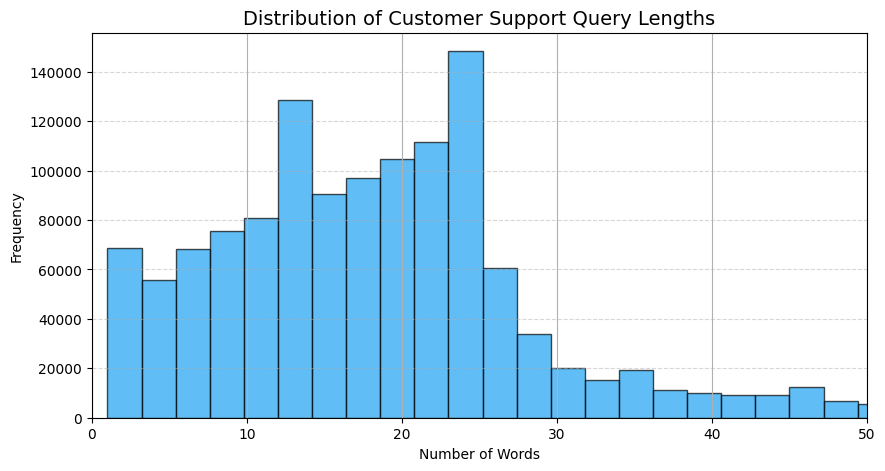

🔤 Extracting Top Keywords...


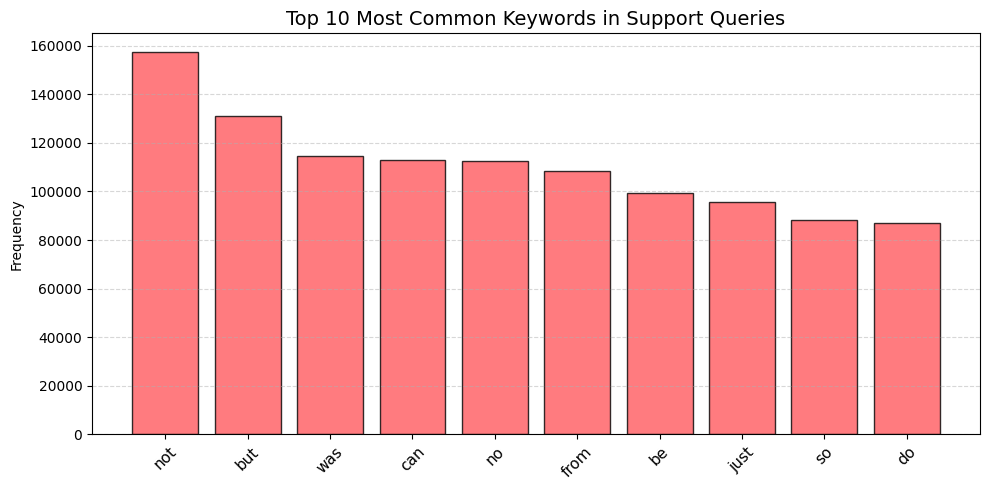

✅ EDA Plots generated and saved in Colab files!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("📊 Loading final dataset from Drive for EDA...")
# قراءة الملف اللي حفظناه
df_clean = pd.read_csv('/content/final_rag_dataset.csv')

# 1. حساب طول الأسئلة (Word Count)
df_clean['q_word_count'] = df_clean['cleaned_question'].astype(str).apply(lambda x: len(x.split()))

print("\n📈 --- Support Data Insights ---")
print(f"Total Processed QA Pairs: {len(df_clean):,}")
print(f"Average Question Length: {df_clean['q_word_count'].mean():.2f} words")

# 2. رسم توزيع أطوال الأسئلة (Plot 1)
print("📸 Generating Word Count Distribution Plot...")
plt.figure(figsize=(10, 5))
df_clean['q_word_count'].hist(bins=50, color='#1DA1F2', edgecolor='black', alpha=0.7)
plt.title('Distribution of Customer Support Query Lengths', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 50) # أغلب التويتات قصيرة
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('query_length_distribution.png', dpi=300)
plt.show()

# 3. تحليل الكلمات الأكثر تكراراً (Plot 2)
print("🔤 Extracting Top Keywords...")
all_words = ' '.join(df_clean['cleaned_question'].astype(str)).split()

# قائمة كلمات شائعة ملهاش معنى تحليلي عشان نشيلها
stop_words = set(['the', 'to', 'i', 'a', 'and', 'my', 'is', 'in', 'it', 'for', 'you', 'on', 'of', 'have', 'with', 'me', 'this', 'that', 'get', 'at', 'your', 'am', 'please', 'help'])
filtered_words = [word for word in all_words if word not in stop_words]

common_words = Counter(filtered_words).most_common(10)
words, counts = zip(*common_words)

# رسم الكلمات الأكثر تكراراً
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='#FF5A5F', alpha=0.8, edgecolor='black')
plt.title('Top 10 Most Common Keywords in Support Queries', fontsize=14)
plt.ylabel('Frequency')
plt.xticks(rotation=45, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top_keywords.png', dpi=300)
plt.show()

print("✅ EDA Plots generated and saved in Colab files!")

In [7]:
import pandas as pd
import numpy as np
import faiss
import pickle
import torch  # ضفنا مكتبة تورش لتحديد الـ Device
from sentence_transformers import SentenceTransformer

# تحديد الـ Device تلقائياً (GPU لو متاح، وإلا CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Execution Device detected: {device.upper()}")

print("🔄 1. Loading 100k rows for low-latency MVP Vector Store...")
df_rag = pd.read_csv('final_rag_dataset.csv', nrows=100000)

questions = df_rag['cleaned_question'].astype(str).tolist()
answers = df_rag['cleaned_answer'].astype(str).tolist()

print("🧠 2. Loading Embedding Model (all-MiniLM-L6-v2)...")
# هنا بنجبر الموديل يروح للـ GPU عبر الـ device configuration
embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

print("⚡ 3. Encoding questions into dense vectors...")
embeddings = embed_model.encode(questions, show_progress_bar=True, batch_size=512, convert_to_numpy=True)

print("🗂️ 4. Building FAISS FlatL2 Index...")
dimension = embeddings.shape[1]

# بناء الـ Index ليتوافق مع الـ GPU أو الـ CPU
if device == "cuda":
    # تجهيز FAISS للعمل على الـ GPU بكفاءة قصوى
    res = faiss.StandardGpuResources()
    index_cpu = faiss.IndexFlatL2(dimension)
    index = faiss.index_cpu_to_gpu(res, 0, index_cpu)
else:
    index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("💾 5. Saving Database Artifacts...")
# لو شغالين GPU بنرجع الـ index للـ CPU عشان نعرف نسيفه كملف عادي
if device == "cuda":
    final_index = faiss.index_gpu_to_cpu(index)
else:
    final_index = index

faiss.write_index(final_index, "faiss_customer_support.index")

with open("qa_metadata.pkl", "wb") as f:
    pickle.dump({'questions': questions, 'answers': answers}, f)

print("✅ DONE! 'faiss_customer_support.index' and 'qa_metadata.pkl' are ready.")

# --- 🧪 Test Function ---
def ask_chatbot(user_query):
    query_vector = embed_model.encode([user_query], convert_to_numpy=True)

    # لو الـ Index الأصلي GPU بنعمل البحث فيه علطول
    distances, indices = index.search(query_vector, k=1)
    best_match_idx = indices[0][0]

    print("\n=== Chatbot Live Test ===")
    print(f"👤 User: {user_query}")
    print(f"🤖 Bot: {answers[best_match_idx]}")
    print(f"⏱️ Distance: {distances[0][0]:.4f}")

# جرب التيست
ask_chatbot("my phone battery is dying so fast after the new update")

🖥️ Execution Device detected: CUDA
🔄 1. Loading 100k rows for low-latency MVP Vector Store...
🧠 2. Loading Embedding Model (all-MiniLM-L6-v2)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⚡ 3. Encoding questions into dense vectors...


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

🗂️ 4. Building FAISS FlatL2 Index...
💾 5. Saving Database Artifacts...
✅ DONE! 'faiss_customer_support.index' and 'qa_metadata.pkl' are ready.

=== Chatbot Live Test ===
👤 User: my phone battery is dying so fast after the new update
🤖 Bot: we can help. can you tell us which version of ios 11 your device is on? that can be found in settings &gt; general &gt; about.
⏱️ Distance: 0.4181


In [1]:
!pip install faiss-gpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 7.1 MB/s eta 0:00:00


In [8]:
# 1. تسطيب مكتبات الـ API والـ Tunneling
!pip install fastapi uvicorn pydantic nest-asyncio pyngrok

import nest_asyncio
from fastapi import FastAPI, HTTPException, Security, Depends
from fastapi.security.api_key import APIKeyHeader
from pydantic import BaseModel
import faiss
import pickle
from sentence_transformers import SentenceTransformer
import uvicorn
from pyngrok import ngrok

# تفعيل الـ Async جوه الكولاب عشان السيرفر يشتغل بدون تهنيج
nest_asyncio.apply()

app = FastAPI(title="Customer Support RAG Production API", description="Milestone 3 Rest API")

# --- إعدادات الحماية والتأمين (Security & Access Control) ---
API_KEY = "LoaySupportSecureKey2026"  # الـ API Key المخصص لحماية الـ Endpoint
api_key_header = APIKeyHeader(name="X-API-KEY", auto_error=True)

def verify_api_key(api_key: str = Depends(api_key_header)):
    if api_key != API_KEY:
        raise HTTPException(status_code=403, detail="Unauthorized: Invalid API Key")
    return api_key

# --- تحميل الموديل والـ الـ Index من الدرايف علطول ---
drive_path = '/content/drive/MyDrive/'
device = "cuda" if torch.cuda.is_available() else "cpu"

print("🔄 Loading FAISS Index and Metadata from Drive...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
index = faiss.read_index(f"{drive_path}faiss_customer_support.index")

with open(f"{drive_path}qa_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)
answers = metadata['answers']
print("✅ API Assets Loaded Successfully!")

# --- تعريف الـ Payload (Request Structure) ---
class ChatQuery(BaseModel):
    query: str

# --- الـ REST API Endpoint ---
@app.post("/chat")
def get_response(payload: ChatQuery, api_key: str = Depends(verify_api_key)):
    # تحويل السؤال لـ Vector
    q_vec = embed_model.encode([payload.query], convert_to_numpy=True)

    # البحث في الـ Index
    distances, indices = index.search(q_vec, k=1)
    best_match_idx = indices[0][0]

    return {
        "status": "success",
        "query": payload.query,
        "retrieved_answer": answers[best_match_idx],
        "confidence_score": float(1 / (1 + distances[0][0])) # تحويل الـ distance لـ score مئوي
    }

# --- تشغيل السيرفر وفتح رابط خارجي للتجربة ---
# ملاحظة: لو عندك حساب ngrok حط الـ Token بتاعك هنا، لو مش معاك هيشتغل برابط مؤقت أو هنشغله local
print("🚀 Starting FastAPI Server...")
# فتح منفذ عام (Public Tunnel) برقم بورت 8000
public_url = ngrok.connect(8000)
print(f"🔗 Public Azure-Ready API Link: {public_url}")

# بدء تشغيل السيرفر جوه الكولاب
uvicorn.run(app, host="0.0.0.0", port=8000)

🔄 Loading FAISS Index and Metadata from Drive...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RuntimeError: Error in faiss::FileIOReader::FileIOReader(const char*) at /project/faiss/impl/io.cpp:69: Error: 'f' failed: could not open /content/drive/MyDrive/faiss_customer_support.index for reading: No such file or directory